# Configurações Iniciais

### Realizando os imports necessários

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### Leitura do dataset

In [ ]:
apps = pd.read_csv('googleplaystore.csv')

### Ajeita linha que possui seus valores na ordem errada

In [ ]:
app = apps.loc[apps['App'] == 'Life Made WI-Fi Touchscreen Photo Frame']

category = app['Android Ver'], 'Category'
rating = float(app['Category'].iloc[0]), 'Rating'
reviews = int(app['Rating'].iloc[0]), 'Reviews'
size = app['Reviews'], 'Size'
installs = app['Size'], 'Installs'
type = app['Installs'], 'Type'
price = app['Type'], 'Price'
content_rating = app['Price'], 'Content Rating'
genres = app['Content Rating'], 'Genres'
last_updated = app['Genres'], 'Last Updated'
current_ver = app['Last Updated'], 'Current Ver'
android_ver = app['Current Ver'], 'Android Ver'

for item in [category, rating, reviews, size, installs, type, price, content_rating, genres, last_updated, current_ver, android_ver]:
    apps.loc[apps['App'] == 'Life Made WI-Fi Touchscreen Photo Frame', [item[1]]] = item[0]

### Alterando as reviews para números, ordenando e então removendo as linhas duplicadas
- Removendo levando em consideração a coluna 'App'.
- Ordenando pelas Reviews, pois levei em consideração que o app com mais reviews é o mais utilizado e, portanto, o mais relevante.

In [ ]:
apps['Reviews'] = pd.to_numeric(
    apps['Reviews'],
    errors='coerce'
)
apps = apps.sort_values('Reviews', ascending=False)
apps = apps.drop_duplicates(subset='App')

### Aplicando filtros e ordenações necessárias

- Optei por não realizar as alterações diretamente na variável responsável pelo DataFrame original, tanto para manter a integridade dos dados, quando para, caso seja necessário, reutilizar os dados gerados.
- erros='coerce' foi utilizado para evitar erros por conta de valores inválidos.
- notna(), para evitar puxar valores nulos.

In [ ]:
apps_por_installs = apps[:]
apps_por_installs['Installs'] = pd.to_numeric(
    apps_por_installs['Installs'].str.replace('+', '').str.replace(',', ''),
    errors='coerce'
)
apps_por_installs = apps_por_installs.sort_values('Installs', ascending=False)

app_por_preco = apps[:]
app_por_preco['Price'] = pd.to_numeric(
    app_por_preco['Price'].str.replace('$', ''),
    errors='coerce'
)
app_por_preco = app_por_preco.sort_values('Price', ascending=False)

apps_por_rating = apps[:]
apps_por_rating['Rating'] = pd.to_numeric(
    apps_por_rating['Rating'],
    errors='coerce'
)
apps_por_rating = apps_por_rating.sort_values('Rating', ascending=False)

apps_gratuitos = apps[
    (apps['Type'] == 'Free')
    & (apps['Rating'].notna())
]

apps_pagos = apps[
    (apps['Type'] == 'Paid')
    & (apps['Rating'].notna())
]

# Processamento de Dados e Análises

### Gráfico contendo os Top 5 aplicativos mais instalados

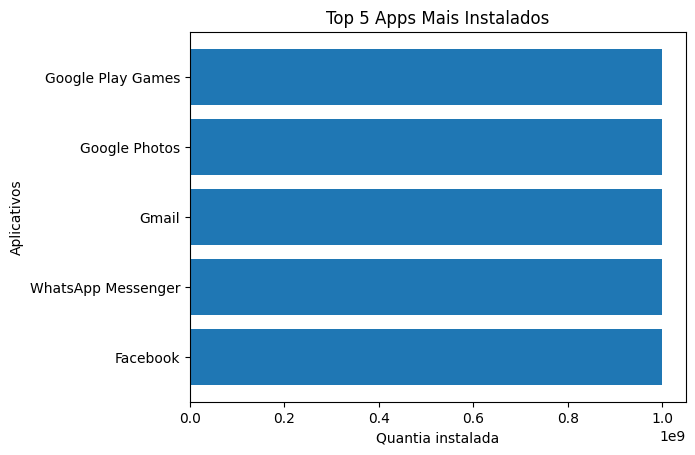

In [26]:
num_apps = 5
plt.barh(apps_por_installs['App'].head(num_apps), apps_por_installs['Installs'].head(num_apps))
plt.xlabel('Quantia instalada')
plt.ylabel('Aplicativos')
plt.title(f'Top {num_apps} Apps Mais Instalados')
plt.show()

### Gráfico com as 5 categorias mais frequentes no dataset

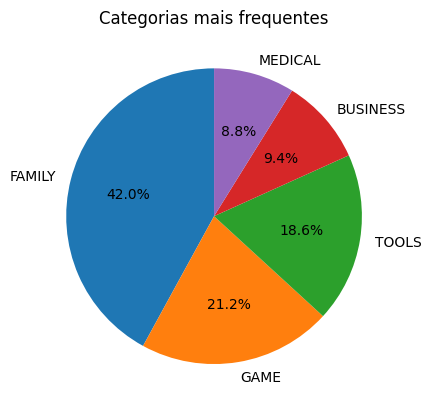

In [27]:
contagem = apps['Category'].value_counts().head(5)
plt.pie(
    contagem.values,
    labels=contagem.index,
    autopct=lambda valor: f'{valor:.1f}%',
    startangle=90
)
plt.title('Categorias mais frequentes')
plt.show()

### Apresenta o aplicativo mais caro em conjunto com seu respectivo preço

In [28]:
app_mais_caro = app_por_preco.head(1)
print(f"O app mais caro presente no dataset é {app_mais_caro['App'].iloc[0]}, custando US${app_mais_caro['Price'].iloc[0]}.")

O app mais caro presente no dataset é I'm Rich - Trump Edition, custando US$400.0.


### Mostra a quantia de aplicativos que contém 'Mature 17+' como Classificação Indicativa

In [29]:
apps_mais_17 = apps.loc[apps['Content Rating'] == 'Mature 17+']
print(f"{len(apps_mais_17)} apps no dataset são classificados como 'Mature 17+'.")

393 apps no dataset são classificados como 'Mature 17+'.


### Top 10 aplicativos ordenados pelo número de reviews
- Utilizei a função zip para unir os nomes dos aplicativos com a quantia de reviews.
- Não precisei ordenar, já que já o havia feito anteriormente.

In [30]:
num_apps = 10
print('Top 10 apps por número de reviews\n')
for i, row in enumerate(zip(apps['App'].head(num_apps), apps['Reviews'].head(num_apps)), 1):
    print(f"{i}. {row[0]}, {row[1]} reviews")

Top 10 apps por número de reviews

1. Facebook, 78158306 reviews
2. WhatsApp Messenger, 69119316 reviews
3. Instagram, 66577446 reviews
4. Messenger – Text and Video Chat for Free, 56646578 reviews
5. Clash of Clans, 44893888 reviews
6. Clean Master- Space Cleaner & Antivirus, 42916526 reviews
7. Subway Surfers, 27725352 reviews
8. YouTube, 25655305 reviews
9. Security Master - Antivirus, VPN, AppLock, Booster, 24900999 reviews
10. Clash Royale, 23136735 reviews


### Top 10 gêneros mais frequentes no dataset em conjunto com seu respectivo app mais bem avaliado
- Foi feito uso de value_counts para obter o gênero e sua respectiva contagem.

In [31]:
num_generos = 10
frequencia_generos = apps['Genres'].value_counts().head(num_generos)
print(f"Top {num_generos} gêneros mais frequentes no dataset em conjunto com seu respectivo app mais bem avaliado\n")
print('Gênero | Frequencia | App')
for i, (genre, count) in enumerate(frequencia_generos.items(), 1):
    best_rating_app = apps_por_rating[
        (apps_por_rating['Genres'] == genre)
        & (apps_por_rating['Rating'].notna())
    ].head(1)
    print(f"{i}. {genre}, {count}, {best_rating_app['App'].iloc[0]}")

Top 10 gêneros mais frequentes no dataset em conjunto com seu respectivo app mais bem avaliado

Gênero | Frequencia | App
1. Tools, 828, ReactNative BG Geolocation
2. Entertainment, 561, CN Resident
3. Education, 510, Florida Wildflowers
4. Business, 420, EB Cash Collections
5. Medical, 395, Labs on Demand
6. Personalization, 376, FO Bixby
7. Productivity, 374, CJ'S TIRE AND AUTO INC.
8. Lifestyle, 368, Unity CF
9. Finance, 345, DN Calculators
10. Sports, 331, FK Dedinje BGD


### App gratuito mais bem avaliado

In [32]:
best_free_app = apps_por_rating.loc[apps_por_rating['Type'] == 'Free'].head(1)
print(f"O aplicativo gratuito mais bem avaliado é o '{best_free_app['App'].iloc[0]}', com uma avaliação de {best_free_app['Rating'].iloc[0]} estrelas.")

O aplicativo gratuito mais bem avaliado é o 'EB Cash Collections', com uma avaliação de 5.0 estrelas.


### Gráfico Boxplot evidenciando as avaliações dos aplicativos que pertencem aos 10 gêneros mais frequentes no dataset
- Fiz uso do isin() para filtrar apenas os aplicativos que pertencem aos 10 gêneros mais frequentes no dataset.
- Foi necessária uma pesquisa para compreender este gráfico muito interessante e informativo que foge do convencional. 

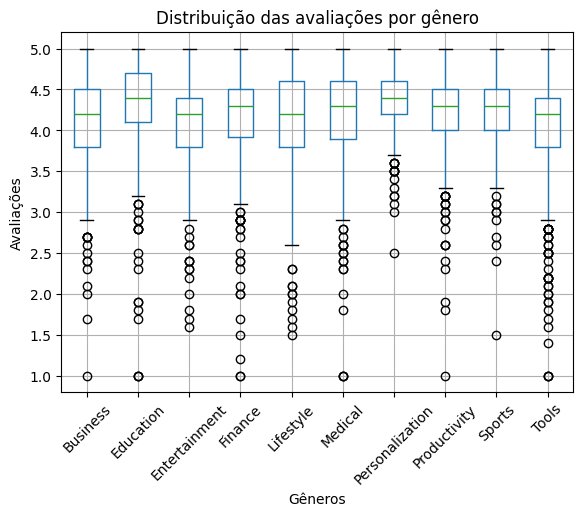

In [33]:
apps_filtrados = apps_por_rating[apps_por_rating['Genres'].isin(frequencia_generos.index)]
apps_filtrados.boxplot(column='Rating', by='Genres', rot=45)
plt.title('Distribuição das avaliações por gênero')
plt.suptitle('')
plt.xlabel('Gêneros')
plt.ylabel('Avaliações')
plt.show()

### Comparação entre as avaliações de aplicativos pagos e gratuitos
- sort_index necessário para manter a ordem correta no gráfico.
- Informações montadas dentro de um for loop para evitar repetição de código.

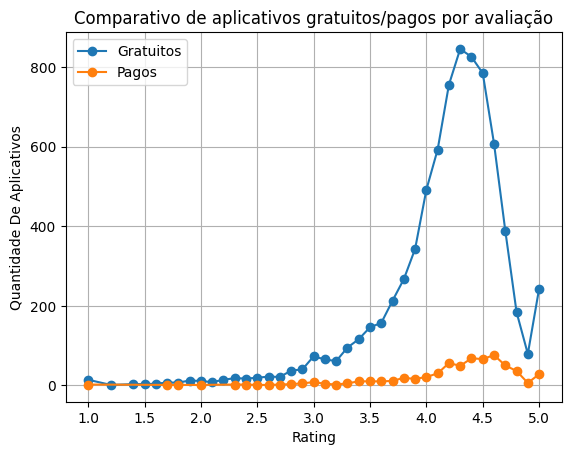

In [34]:
gratuitos_por_rating = apps_gratuitos['Rating'].value_counts().sort_index(), 'Gratuitos'
pagos_por_rating = apps_pagos['Rating'].value_counts().sort_index(), 'Pagos'

for tipo in [gratuitos_por_rating, pagos_por_rating]:
    plt.plot(
        tipo[0].index,
        tipo[0].values,
        label=tipo[1],
        marker='o'
    )
plt.title('Comparativo de aplicativos gratuitos/pagos por avaliação')
plt.xlabel('Rating')
plt.ylabel('Quantidade De Aplicativos')
plt.grid(True)
plt.legend()
plt.show()